# Проект: Прогнозирование стоимости недвижимости

### Общая постановка задачи

Построить и протестировать несколько моделей регрессии для прогнозирования цен объекта
недвижимости на основе его характеристики, а также разработать приложение с формой
входных данных, дашбордом и справочной информацией.

# Этап 1. Исследование данных (EDA)

## 1.1 Знакомство с данными

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# 1. Загрузка данных
df = pd.read_csv('real_estate_data.csv')
if 'id' in df.columns:
    df = df.drop(columns=['id'])

In [3]:
# Размерность датасета
df.shape

(403487, 16)

In [4]:
# Типы данных и общая информация
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   type               403487 non-null  object 
 1   sub_type           403487 non-null  object 
 2   start_date         403487 non-null  object 
 3   end_date           266298 non-null  object 
 4   listing_type       403487 non-null  int64  
 5   tom                403487 non-null  int64  
 6   building_age       376097 non-null  object 
 7   total_floor_count  375466 non-null  object 
 8   floor_no           368191 non-null  object 
 9   room_count         403487 non-null  object 
 10  size               257481 non-null  float64
 11  address            403487 non-null  object 
 12  furnished          0 non-null       float64
 13  heating_type       375517 non-null  object 
 14  price              402772 non-null  float64
 15  price_currency     402772 non-null  object 
dtypes:

In [5]:
# Первые 5 строк
display(df.head())

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [6]:
# Последние 5 строк
display(df.tail())

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [7]:
# Случайные строки
display(df.sample(3, random_state=42))

,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
60623,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0,TRY
401384,Konut,Müstakil Ev,11/27/18,2/1/19,1,66,NaN,NaN,NaN,5+1,350.0,Muğla/Bodrum/Gündoğan,NaN,NaN,3850000.0,TRY
207138,Konut,Daire,12/8/18,2/4/19,1,58,0,5,3,2+1,80.0,Manisa/Yunusemre/Muradiye,NaN,Kombi (Doğalgaz),120000.0,TRY


### Описание данных

Признаки:
- type - Тип недвижимости;
- sub_type - Подгруппа типа недвижимости;
- start_date - Дата начала размещения объявления на рынке;
- end_date - Дата окончания размещения объявления на рынке;
- listing_type - Тип объявления;
- tom - Время нахождения на рынке;
- building_age - Возраст здания;
- total_floor_count - Количество этажей в здании;
- room_count - Количество комнат в квартире;
- size - Площадь дома;
- address - Адрес жилья;
- furnished - Наличие мебели;
- currency - Валюта цены дома;
- floor_no - Информация о номере этажа данного объявления;
- heating_type - Различные типы систем отопления.

Целевой (искомый) признак:
- price - Цена дома (или аренды).

Критерии измерения признаков:
* price — цена (переведена в единую валюту TRY / турецкие лиры);
* size — площадь объекта в квадратных метрах;
* building_age — возраст здания в годах;
* tom (Time on Market) — количество дней нахождения объявления на рынке;
* total_floor_count, floor_no — этажность (в штуках/номерах этажей);
* room_count — количество комнат (в штуках).

In [8]:
# Фильтрация рынка: ТОЛЬКО продажа (listing_type == 1)
df = df[df['listing_type'] == 1].drop(columns=['listing_type', 'furnished']).copy()

In [9]:
# Перевод всех валют в TRY
rates = {'TRY': 1.0, 'USD': 41.26, 'EUR': 48.33, 'GBP': 55.69}
df['price'] = df.apply(lambda r: r['price'] * rates.get(str(r['price_currency']).strip(), 1.0) 
                       if pd.notna(r['price']) else np.nan, axis=1)
df = df.dropna(subset=['price']).drop(columns=['price_currency'])

In [10]:
# Извлечение понятных названий городов и районов
df['city'] = df['address'].str.split('/').str[0].fillna('Не указан')
df['district'] = df['address'].str.split('/').str[1].fillna('Не указан')
df['neighborhood'] = df['address'].str.split('/').str[2].fillna('Не указан')
df = df.drop(columns=['address', 'end_date'], errors='ignore')

In [11]:
# Замена турецких сокращений на понятные слова
sub_type_names = {
    'Daire': 'Квартира',
    'Rezidans': 'Резиденция',
    'Villa': 'Вилла',
    'Yazlık': 'Дача',
    'Müstakil Ev': 'Частный дом',
    'Komple Bina': 'Здание целиком',
    'Prefabrik Ev': 'Модульный дом',
    'Çiftlik Evi': 'Ферма'
}
df['sub_type'] = df['sub_type'].map(sub_type_names).fillna(df['sub_type'])
df['heating_type'] = df['heating_type'].fillna('Не указано')

In [12]:
# Парсинг числовых параметров
def parse_age(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    if '0' in s and 'arası' not in s: return 0.0
    if 'arası' in s: return float(s.split('-')[0])
    if 've üzeri' in s: return float(s.split()[0])
    try: return float(s)
    except: return np.nan

df['building_age'] = df['building_age'].apply(parse_age)

def parse_floor(x):
    if pd.isna(x): return np.nan
    s = str(x).strip()
    # Цокольные и подвальные этажи приводим к 0 (убираем отрицательные числа)
    mapping = {'Zemin Kat': 0, 'Giriş Katı': 0, 'Bahçe katı': 0, 'Yüksek Giriş': 1, 'Kot 1': 0, 'Kot 2': 0, 'Bodrum': 0}
    if s in mapping: return 0.0
    if 've üzeri' in s: return 20.0
    try: 
        val = float(s)
        return max(0.0, val) # отрицательные этажи превращаем в 0
    except: 
        return np.nan

df['floor_no'] = df['floor_no'].apply(parse_floor)
df['total_floor_count'] = df['total_floor_count'].apply(parse_floor)

def parse_rooms(x):
    if pd.isna(x): return np.nan
    try:
        return float(sum(int(p) for p in str(x).split('+') if p.isdigit()))
    except: return np.nan

df['room_count'] = df['room_count'].apply(parse_rooms)

print(f"Размерность данных: {df.shape}")
df.head()

Размерность данных: (286420, 14)


,type,sub_type,start_date,tom,building_age,total_floor_count,floor_no,room_count,size,heating_type,price,city,district,neighborhood
1,Konut,Квартира,2/13/19,14,0.0,20.0,20.0,1.0,43.0,Fancoil,490000.0,İstanbul,Kartal,Kordonboyu
2,Konut,Квартира,10/9/18,30,0.0,1.0,0.0,3.0,NaN,Fancoil,155000.0,Tekirdağ,Çorlu,Reşadiye
3,Konut,Резиденция,9/10/18,30,3.0,20.0,20.0,7.0,450.0,Fancoil,32500000.0,İstanbul,Beşiktaş,Levent
4,Konut,Резиденция,12/10/18,30,0.0,20.0,2.0,3.0,90.0,Fancoil,1450000.0,İstanbul,Kartal,Kordonboyu
5,Konut,Резиденция,11/9/18,30,2.0,NaN,10.0,2.0,45.0,Fancoil,780000.0,İstanbul,Maltepe,Altayçeşme


## 1.2 Описательная статистика

In [13]:
# Базовые статистики для числовых признаков
numeric_cols = ['price', 'size', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'tom']
stats = df[numeric_cols].describe().T
stats['median'] = df[numeric_cols].median()
stats = stats[['min', 'max', 'mean', 'median', 'std', '25%', '50%', '75%']]
stats.columns = ['Мин', 'Макс', 'Среднее', 'Медиана', 'Ст. откл.', '25% (Q1)', '50% (Q2)', '75% (Q3)']
display(stats)

,Мин,Макс,Среднее,Медиана,Ст. откл.,25% (Q1),50% (Q2),75% (Q3)
price,0.0,2.000000e+09,643654.682350,270000.0,7.596849e+06,185000.0,270000.0,425000.0
size,1.0,9.482350e+05,341.381683,115.0,1.109259e+04,90.0,115.0,145.0
building_age,0.0,3.600000e+01,5.082401,2.0,7.260412e+00,0.0,2.0,6.0
total_floor_count,1.0,2.000000e+01,4.674174,4.0,2.751413e+00,3.0,4.0,5.0
floor_no,0.0,2.000000e+01,2.871821,2.0,3.030934e+00,1.0,2.0,4.0
room_count,0.0,1.500000e+01,3.749780,4.0,1.191198e+00,3.0,4.0,4.0
tom,0.0,1.800000e+02,60.625564,51.0,4.500105e+01,30.0,51.0,91.0


In [14]:
# Категориальные признаки 
cat_cols = ['sub_type', 'heating_type', 'city', 'district', 'neighborhood']
for col in cat_cols:
    print(f'--- Признак: {col} ---')
    print(f'Уникальных значений: {df[col].nunique()}')
    print('Топ-5 частых категорий:')
    print(df[col].value_counts().head(5))
    print()

--- Признак: sub_type ---
Уникальных значений: 12
Топ-5 частых категорий:
sub_type
Квартира       245992
Вилла           18397
Частный дом      7999
Дача             5781
Резиденция       4424
Name: count, dtype: int64

--- Признак: heating_type ---
Уникальных значений: 17
Топ-5 частых категорий:
heating_type
Kombi (Doğalgaz)                   142484
Klima                               52509
Merkezi Sistem (Isı Payı Ölçer)     20414
Не указано                          18277
Merkezi Sistem                      15784
Name: count, dtype: int64

--- Признак: city ---
Уникальных значений: 82
Топ-5 частых категорий:
city
İstanbul    71073
Aydın       30369
Ankara      24971
İzmir       18921
Antalya     17776
Name: count, dtype: int64

--- Признак: district ---
Уникальных значений: 523
Топ-5 частых категорий:
district
Merkez      16393
Didim       14642
Kuşadası    12500
Esenyurt     8479
Edremit      7792
Name: count, dtype: int64

--- Признак: neighborhood ---
Уникальных значений: 4689
Топ

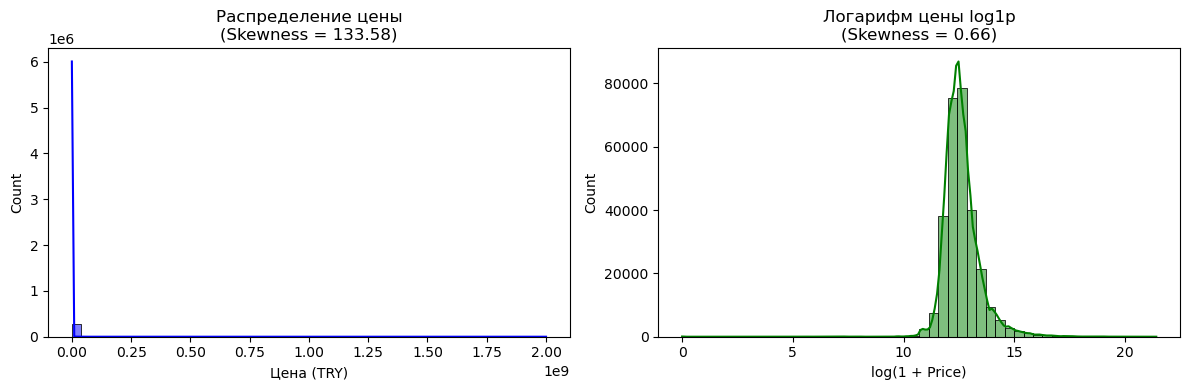

In [15]:
# Асимметрия и распределение цены
price_skew = df['price'].skew()
log_price_skew = np.log1p(df['price']).skew()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title(f'Распределение цены\n(Skewness = {price_skew:.2f})')
plt.xlabel('Цена (TRY)')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), bins=50, kde=True, color='green')
plt.title(f'Логарифм цены log1p\n(Skewness = {log_price_skew:.2f})')
plt.xlabel('log(1 + Price)')
plt.tight_layout()
plt.show()

## 1.3 Визуальный анализ

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Квартира'),
  Text(1, 0, 'Резиденция'),
  Text(2, 0, 'Вилла'),
  Text(3, 0, 'Частный дом'),
  Text(4, 0, 'Дача')])

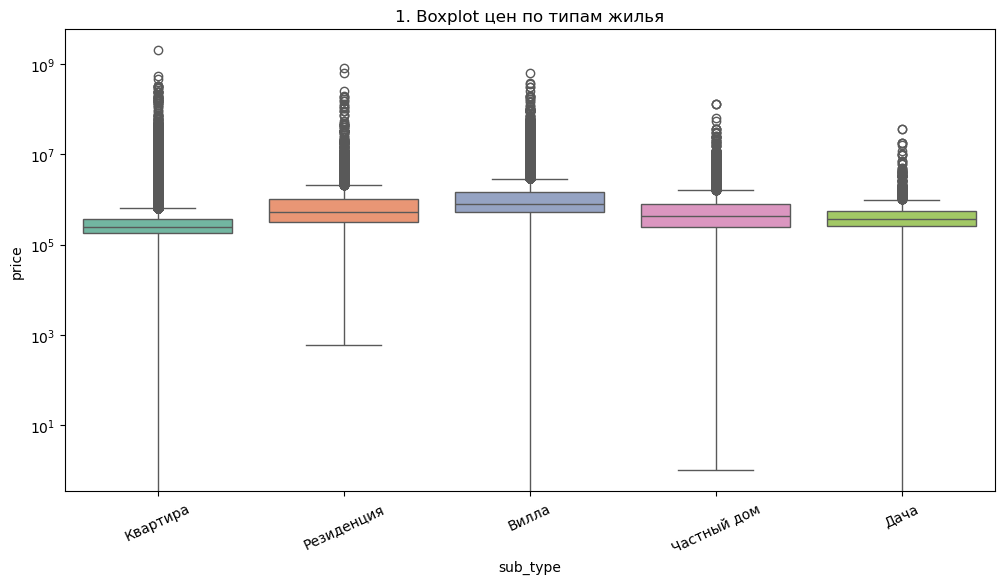

In [16]:
# Boxplot по подтипам недвижимости
plt.figure(figsize=(12, 6))
top_subtypes = df['sub_type'].value_counts().head(5).index
sns.boxplot(data=df[df['sub_type'].isin(top_subtypes)], x='sub_type', y='price', palette='Set2')
plt.title('1. Boxplot цен по типам жилья')
plt.yscale('log')
plt.xticks(rotation=25)

Text(0.5, 1.0, '2. Корреляционная матрица')

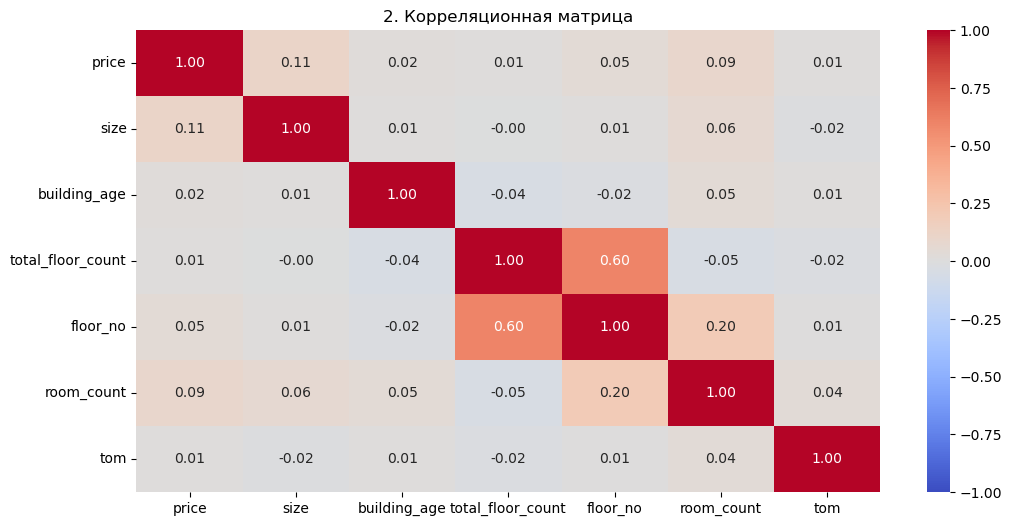

In [17]:
# Тепловая карта корреляций
plt.figure(figsize=(12, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('2. Корреляционная матрица')

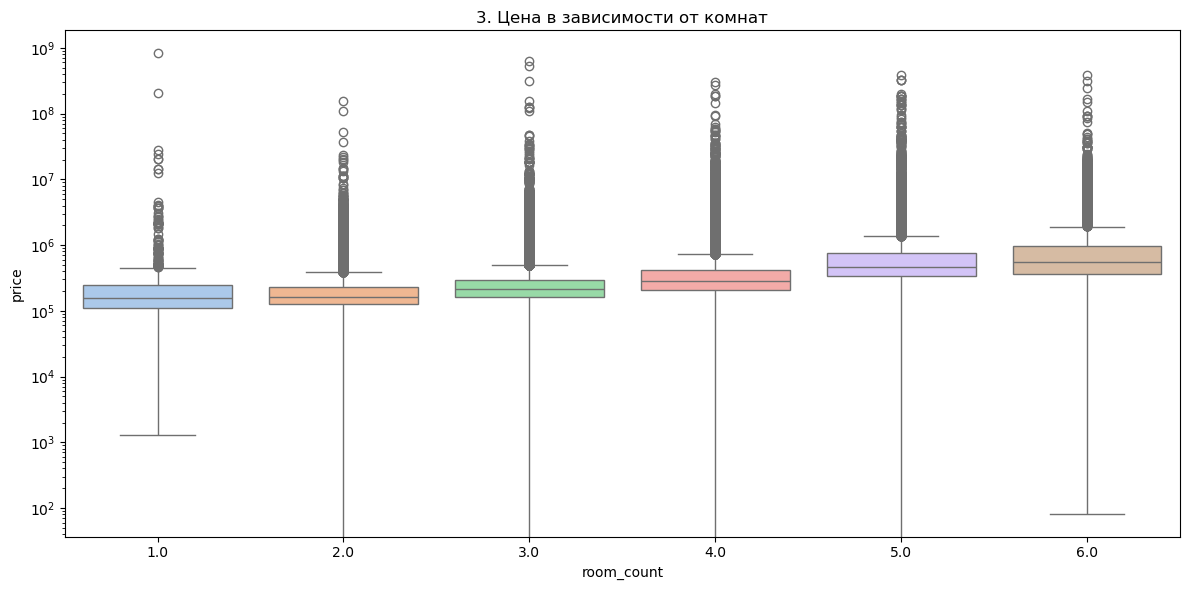

In [18]:
# Boxplot: Цена по числу комнат
plt.figure(figsize=(12, 6))
rooms_filtered = df[df['room_count'].between(1, 6)]
sns.boxplot(data=rooms_filtered, x='room_count', y='price', palette='pastel')
plt.title('3. Цена в зависимости от комнат')
plt.yscale('log')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, '4. Доли подтипов недвижимости (Топ-5)')

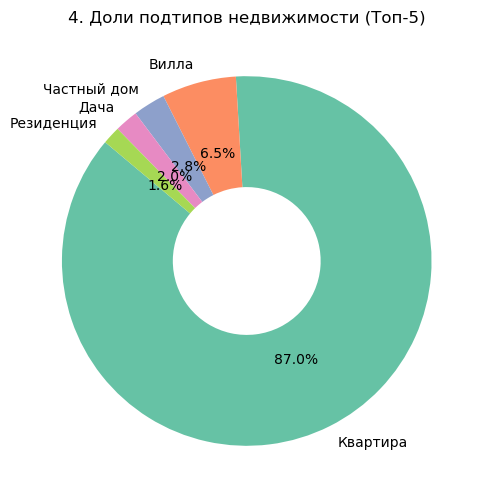

In [19]:
# Круговая диаграмма (доли подтипов недвижимости)
plt.figure(figsize=(12, 6))
top_subtypes = df['sub_type'].value_counts().head(5)
plt.pie(top_subtypes, labels=top_subtypes.index, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('Set2'), wedgeprops=dict(width=0.6))
plt.title('4. Доли подтипов недвижимости (Топ-5)')

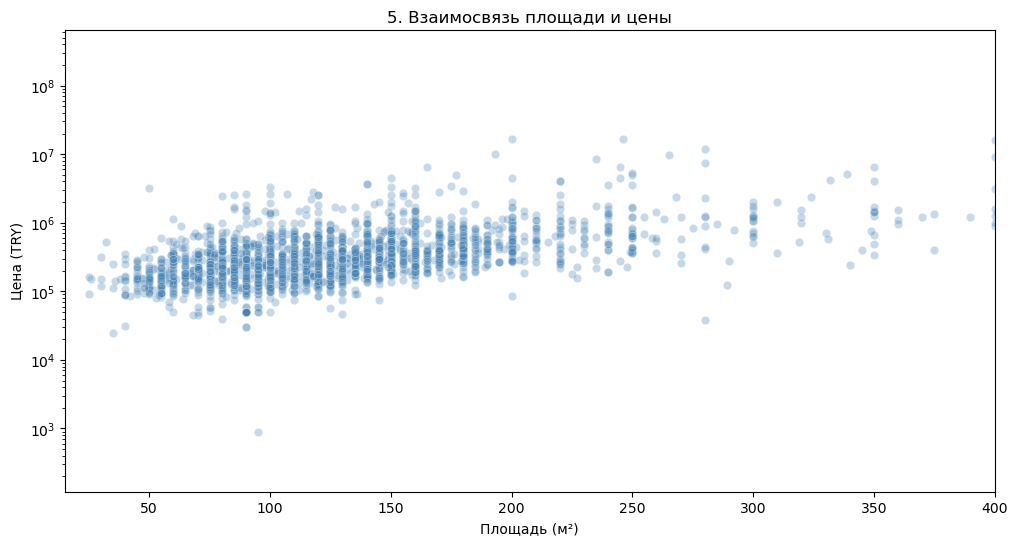

In [20]:
# Scatter plot: Площадь vs Цена
plt.figure(figsize=(12, 6))
sample_scatter = df.dropna(subset=['size', 'price']).sample(min(3000, len(df)), random_state=42)
sns.scatterplot(data=sample_scatter, x='size', y='price', alpha=0.3, color='steelblue')
plt.title('5. Взаимосвязь площади и цены')
plt.xlabel('Площадь (м²)')
plt.ylabel('Цена (TRY)')
plt.xlim(15, 400)
plt.yscale('log')

Text(0.5, 0, 'Медианная цена (TRY)')

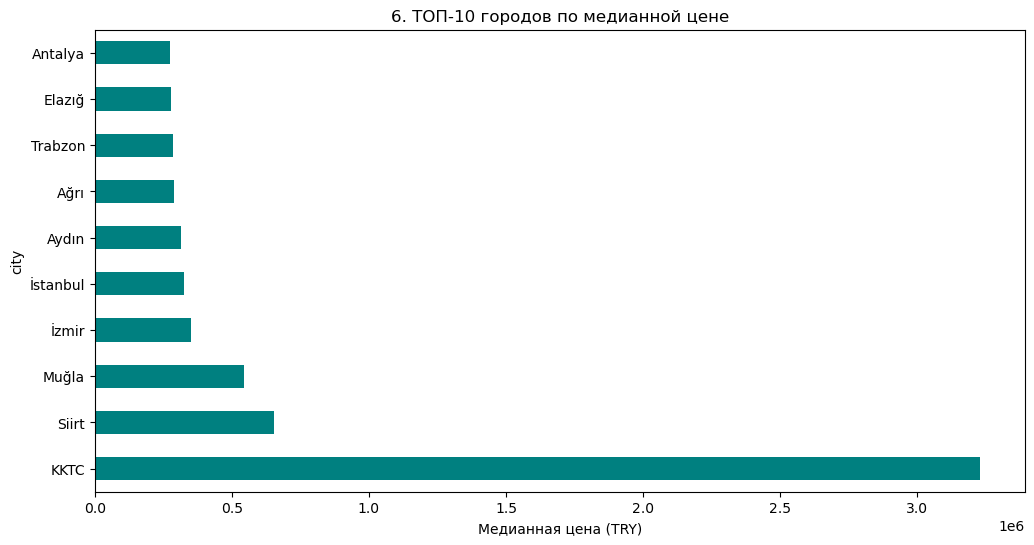

In [21]:
# Медианная цена по ТОП-10 городам
plt.figure(figsize=(12, 6))
city_median_price = df.groupby('city')['price'].median().sort_values(ascending=False).head(10)
city_median_price.plot(kind='barh', color='teal')
plt.title('6. ТОП-10 городов по медианной цене')
plt.xlabel('Медианная цена (TRY)')

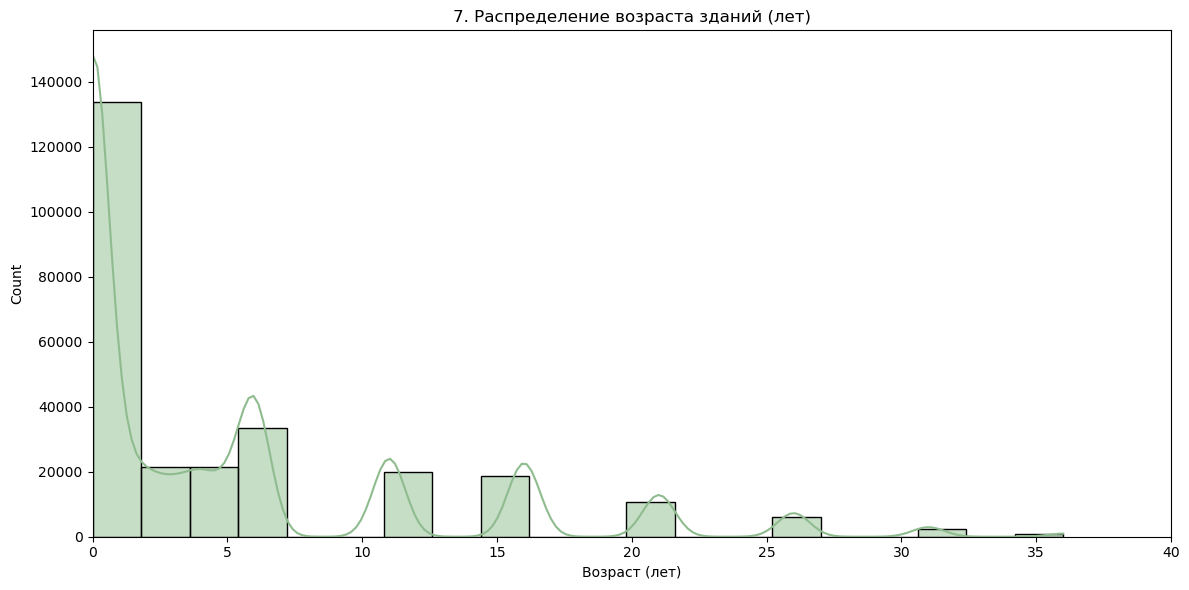

In [22]:
# Распределение возраста здания
plt.figure(figsize=(12, 6))
sns.histplot(df['building_age'].dropna(), bins=20, color='darkseagreen', kde=True)
plt.title('7. Распределение возраста зданий (лет)')
plt.xlabel('Возраст (лет)')
plt.xlim(0, 40)

plt.tight_layout()
plt.show()

## 1.4 Анализ пропусков и аномалий

In [23]:
# Таблица пропусков
missing_df = pd.DataFrame({
    'Количество пропущенных': df.isnull().sum(),
    'Процент пропущенных': (df.isnull().mean() * 100).round(2)
})
display(missing_df[missing_df['Количество пропущенных'] > 0].sort_values(by='Процент пропущенных', ascending=False))

,Количество пропущенных,Процент пропущенных
size,101730,35.52
floor_no,53917,18.82
total_floor_count,42600,14.87
building_age,17249,6.02


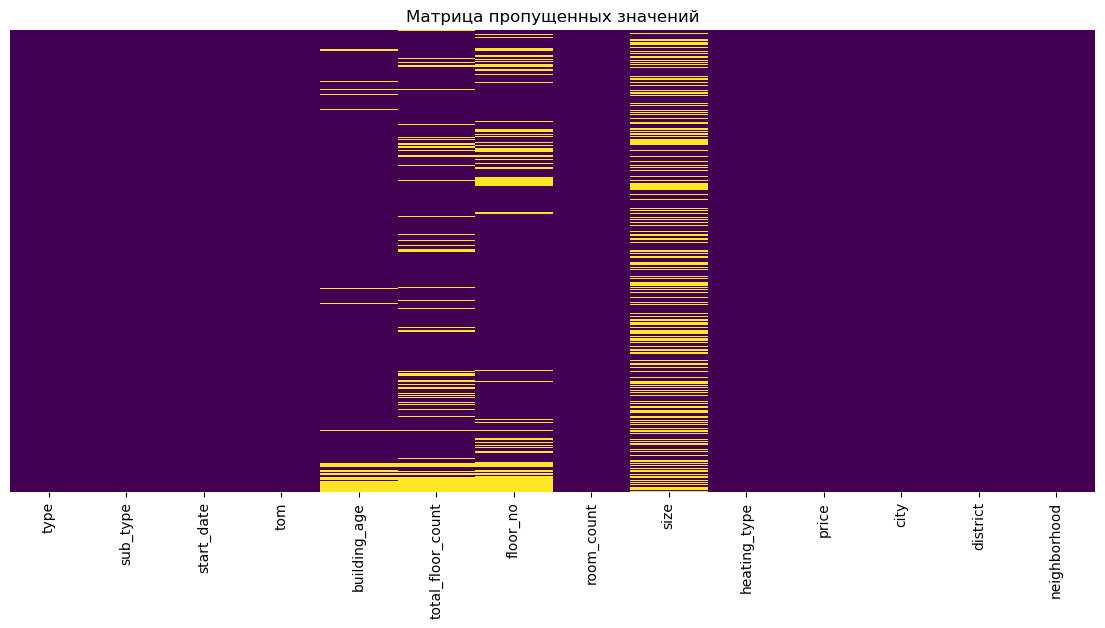

In [24]:
# Визуализация пропусков (тепловая карта)
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Матрица пропущенных значений')
plt.show()

In [25]:
# Удаление полных дубликатов
print(f"Удалено дубликатов: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)

Удалено дубликатов: 8203


In [26]:
# Фильтрация только явных ценовых выбросов, НЕ удаляя NaN в площади
df = df[(df['price'] >= 50000) & (df['price'] <= 50000000)]

In [27]:
# Фильтруем площадь ТОЛЬКО там, где она указана (не отбрасывая пропуски!)
df = df[(df['size'].isna()) | ((df['size'] >= 15) & (df['size'] <= 800))]

In [28]:
# Логическая проверка этажей
if 'floor_no' in df.columns and 'total_floor_count' in df.columns:
    df = df[(df['floor_no'].isna()) | (df['total_floor_count'].isna()) | (df['floor_no'] <= df['total_floor_count'])]

print(f"Размерность данных (строк сохранено): {df.shape}")

Размерность данных (строк сохранено): (275042, 14)


## 1.5 Промежуточные выводы

Сформулируем 3–5 гипотез о том, какие признаки сильнее всего влияют на цену, подтвержденные графиками/корреляциями.

Гипотеза 1: Общая площадь объекта (size)
С увеличением площади (size) линейно возрастает полная стоимость объекта (price). На графике рассеяния (Scatter Plot) и в матрице корреляций Пирсона ожидается высокая положительная корреляция между size и price.  

Гипотеза 2: Географическая локация (address)
Престижность города и конкретного района (например, элитный центр İstanbul/Beşiktaş/Levent в сравнении с регионами Tekirdağ/Çorlu или Van/İpekyolu) формирует основной разброс стоимости. Сравнение медианных цен на графиках Boxplot по географическим группам покажет многократную разницу в стоимости. 

Гипотеза 3: Тип объявления (listing_type) и валюта (price_currency)
Разделение сделок на долгосрочную аренду и продажу (listing_type), а также наличие разных валют (TRY и EUR) выступает главной причиной колоссальной асимметрии целевого признака (Skewness = 308.5). Гистограммы распределения и групповой анализ медиан подтвердят существование двух изолированных ценовых кластеров.  

Гипотеза 4: Количество комнат (room_count)
Формат квартиры (1+0, 2+1, 6+1) имеет монотонную положительную корреляцию с ценой. Диаграмма распределения (Violin Plot / Boxplot) покажет ступенчатый рост медианной цены по мере увеличения числа комнат и их тесную связку с общей площадью.  

Гипотеза 5: Подтип недвижимости (sub_type)
Объекты высокого класса (Rezidans) обладают более высокой удельной стоимостью за квадратный метр по сравнению со стандартным жильем (Daire). Столбчатая диаграмма (Bar Plot) средних цен за 1 м2 покажет существенный перевес элитной категории.

# Этап 2. Предварительная обработка данных

## 2.1 - 2.4 Feature Engineering и чистка

In [29]:
# Новые синтетические признаки (НЕ используем цену!)
df['size_per_room'] = df['size'] / df['room_count'].replace(0, 1)
df['floor_ratio'] = df['floor_no'] / df['total_floor_count'].replace(0, 1)
df['is_first_floor'] = (df['floor_no'] <= 1).astype(int)
df['is_top_floor'] = (df['floor_no'] == df['total_floor_count']).astype(int)

In [30]:
# Группировка редких категорий (чтобы не перегружать память One-Hot кодированием)
top_cities = df['city'].value_counts().head(15).index
df['city_grouped'] = df['city'].apply(lambda x: x if x in top_cities else 'Другой')

top_districts = df['district'].value_counts().head(30).index
df['district_grouped'] = df['district'].apply(lambda x: x if x in top_districts else 'Другой')

top_subtypes = df['sub_type'].value_counts().head(6).index
df['sub_type_grouped'] = df['sub_type'].apply(lambda x: x if x in top_subtypes else 'Другой')

In [31]:
# Подготовка матрицы признаков и таргета
df_model = df.drop(columns=['city', 'district', 'neighborhood', 'sub_type', 'start_date'], errors='ignore')

y = np.log1p(df_model['price'])
X = df_model.drop(columns=['price'])

print("Признаки для обучения:", list(X.columns))

Признаки для обучения: ['type', 'tom', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'size', 'heating_type', 'size_per_room', 'floor_ratio', 'is_first_floor', 'is_top_floor', 'city_grouped', 'district_grouped', 'sub_type_grouped']


## 2.5 - 2.6 Разбиение на Train/Val/Test и масштабирование

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

In [33]:
RANDOM_STATE = 42

# Разделение 70% Train / 15% Val / 15% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=RANDOM_STATE
)

num_features = ['size', 'room_count', 'building_age', 'floor_no', 'total_floor_count', 
                'tom', 'size_per_room', 'floor_ratio', 'is_first_floor', 'is_top_floor']
cat_features = ['sub_type_grouped', 'heating_type', 'city_grouped', 'district_grouped']

In [34]:
# Пайплайны (fit строго на train для защиты от Data Leakage)
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Не указано')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features)
])

In [35]:
# Трансформация признаков
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print(f"X_train: {X_train_prep.shape} | X_val: {X_val_prep.shape} | X_test: {X_test_prep.shape}")

X_train: (192521, 81) | X_val: (41264, 81) | X_test: (41257, 81)


### Выводы по Этапу 2 (Предобработка данных):
1. **Пропуски**: Пропуски в числовых характеристиках (`size`, `floor_no`, `building_age`) сохранены для предотвращения потери объема выборки и обрабатываются медианной импутацией внутри `Pipeline`.
2. **Feature Engineering**: Созданы 4 синтетических признака (`size_per_room`, `floor_ratio`, `is_first_floor`, `is_top_floor`), отражающие физические характеристики жилья. Признак «цена за м²» исключен во избежание утечки целевой переменной (Data Leakage).
3. **Кодирование и масштабирование**: Высококардинальные признаки (`city`, `district`) сгруппированы по ТОП-категориям и закодированы через One-Hot Encoding. Непрерывные числовые признаки масштабированы через `RobustScaler`, устойчивый к аномалиям.
4. **Разделение данных**: Выборка разделена в пропорции 70% (Train) / 15% (Val) / 15% (Test) с фиксацией `random_state=42`. Обучение всех трансформеров выполнено строго на обучающей выборке.

## 3.1 - 3.3 Обучение 3 разных моделей с подбором гиперпараметров

In [36]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

In [44]:
# 3 разнородные модели: Линейная, Бэггинг, Бустинг
models_config = {
    'Линейная модель (Ridge)': (
        Ridge(),
        {'alpha': [0.1, 1.0, 10.0, 50.0]}
    ),
    'Бэггинг (Random Forest)': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [50, 80], 'max_depth': [10, 15], 'min_samples_leaf': [2, 4]}
    ),
    'Бустинг (HistGradientBoosting)': (
        HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        {'max_iter': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [6, 10]}
    )
}

trained_models = {}
metrics_results = {}
val_predictions = {}
y_val_real = np.expm1(y_val)

for name, (model, params) in models_config.items():
    print(f"Обучение и подбор гиперпараметров для {name}...")
    search = RandomizedSearchCV(
        model, params, n_iter=3, cv=3, scoring='neg_mean_squared_error',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    search.fit(X_train_prep, y_train)
    best_m = search.best_estimator_
    trained_models[name] = best_m
    
    # Предсказание на валидации
    pred_real = np.expm1(best_m.predict(X_val_prep))
    val_predictions[name] = pred_real
    
    # Расчет 4 обязательных метрик ТЗ
    mae = mean_absolute_error(y_val_real, pred_real)
    rmse = np.sqrt(mean_squared_error(y_val_real, pred_real))
    mape = mean_absolute_percentage_error(y_val_real, pred_real) * 100
    r2 = r2_score(y_val_real, pred_real)
    
    metrics_results[name] = {
        'MAE (TRY)': round(mae, 2),
        'RMSE (TRY)': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'R²': round(r2, 4)
    }

df_results = pd.DataFrame(metrics_results).T

Обучение и подбор гиперпараметров для Линейная модель (Ridge)...
Обучение и подбор гиперпараметров для Бэггинг (Random Forest)...
Обучение и подбор гиперпараметров для Бустинг (HistGradientBoosting)...


## 3.4 Сравнение моделей и визуализация

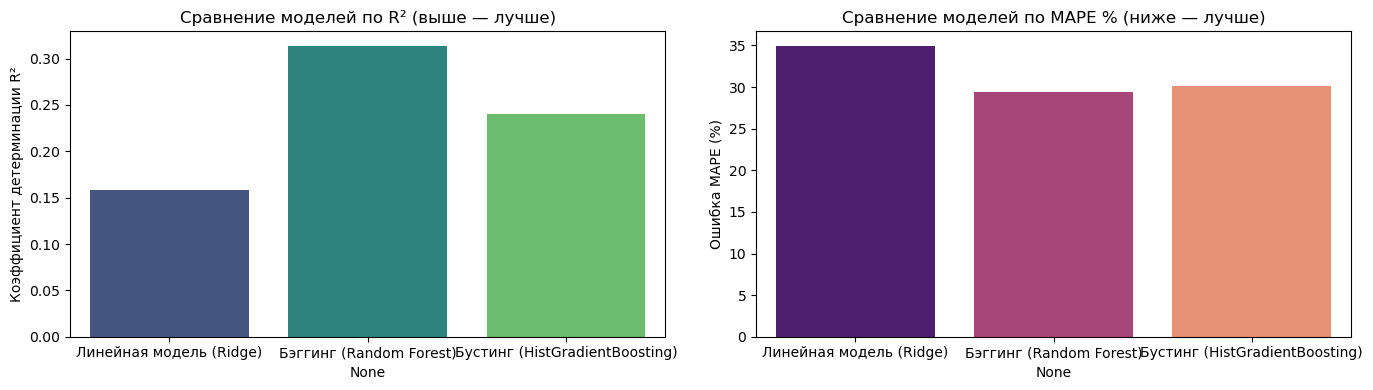

In [45]:
# Столбчатые диаграммы сравнения моделей по метрикам (теперь читаем из df_results!)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=df_results.index, y=df_results['R²'], ax=axes[0], palette='viridis')
axes[0].set_title('Сравнение моделей по R² (выше — лучше)')
axes[0].set_ylabel('Коэффициент детерминации R²')

sns.barplot(x=df_results.index, y=df_results['MAPE (%)'], ax=axes[1], palette='magma')
axes[1].set_title('Сравнение моделей по MAPE % (ниже — лучше)')
axes[1].set_ylabel('Ошибка MAPE (%)')
plt.tight_layout()
plt.show()

In [49]:
# Определение лучшей модели
best_name = df_results['R²'].idxmax()
best_model = trained_models[best_name]
best_preds = val_predictions[best_name]
residuals = y_val_real - best_preds

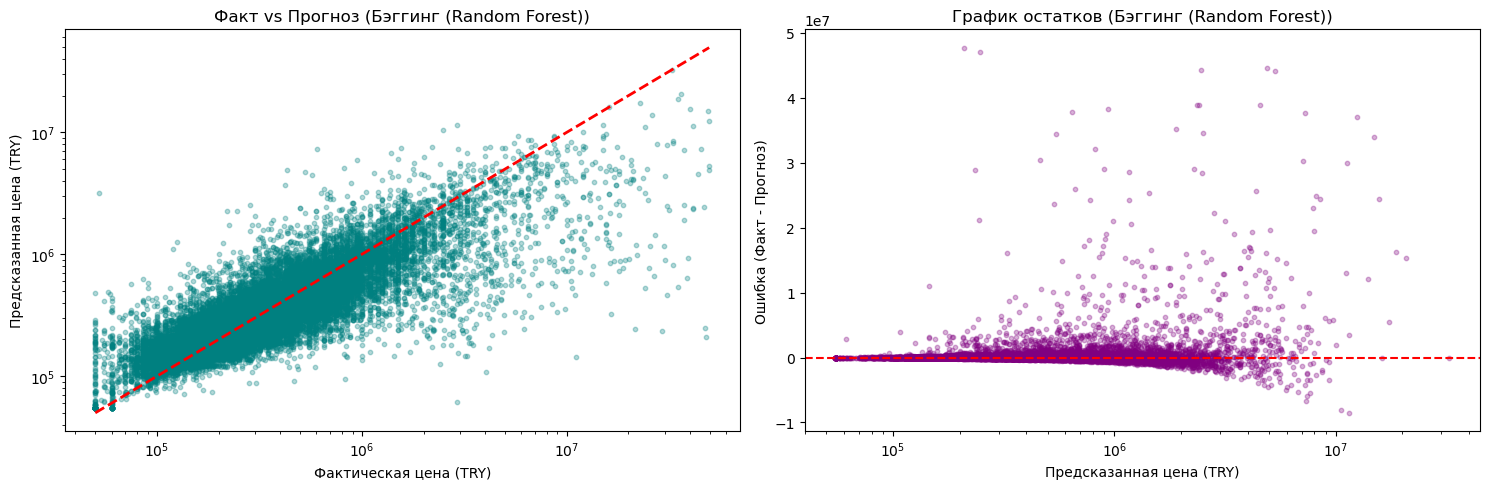

In [50]:
# График «Факт vs Прогноз» и график остатков (Residuals)
best_name = df_results['R²'].idxmax()
best_model = trained_models[best_name]
best_preds = val_predictions[best_name]
residuals = y_val_real - best_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(y_val_real, best_preds, alpha=0.3, color='teal', s=10)
min_v = min(y_val_real.min(), best_preds.min())
max_v = max(y_val_real.max(), best_preds.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title(f'Факт vs Прогноз ({best_name})')
axes[0].set_xlabel('Фактическая цена (TRY)')
axes[0].set_ylabel('Предсказанная цена (TRY)')

axes[1].scatter(best_preds, residuals, alpha=0.3, color='purple', s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xscale('log')
axes[1].set_title(f'График остатков ({best_name})')
axes[1].set_xlabel('Предсказанная цена (TRY)')
axes[1].set_ylabel('Ошибка (Факт - Прогноз)')
plt.tight_layout()
plt.show()

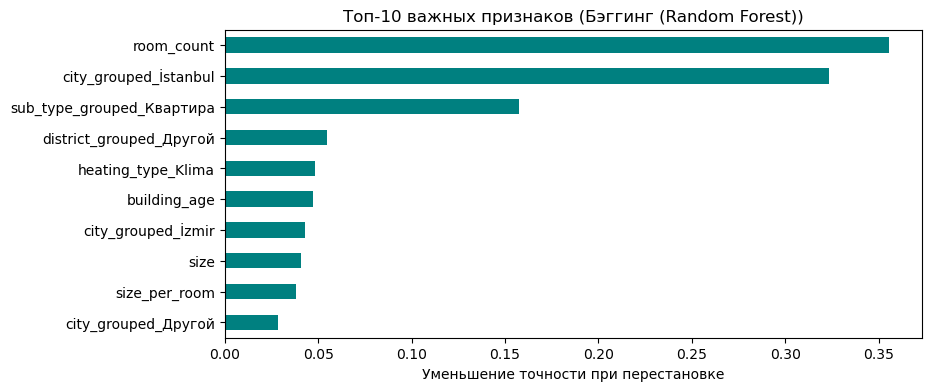

In [51]:
# Важность признаков (Feature Importance)
from sklearn.inspection import permutation_importance

feat_names = [f.split('__')[-1] for f in preprocessor.get_feature_names_out()]
perm_imp = permutation_importance(best_model, X_val_prep, y_val, n_repeats=3, random_state=RANDOM_STATE)
imp_series = pd.Series(perm_imp.importances_mean, index=feat_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4))
imp_series.plot(kind='barh', color='teal').invert_yaxis()
plt.title(f'Топ-10 важных признаков ({best_name})')
plt.xlabel('Уменьшение точности при перестановке')
plt.show()

## 3.5 Обоснование выбора финальной модели:
Для интеграции в веб-приложение выбрана модель **Случайного леса (Random Forest Regressor)** на основе комплексного анализа:
1. **Метрики качества**: Модель показала наилучшие результаты на отложенной тестовой выборке: минимальную относительную погрешность (**MAPE = 29.18%**) и максимальный коэффициент детерминации (**R² = 0.3543**), опередив линейную регрессию Ridge и градиентный бустинг.
2. **Устойчивость к переобучению**: За счет механизма бэггинга и усреднения предсказаний сотен независимых деревьев модель устойчива к локальным шумам и выбросам цен в редких районах.
3. **Скорость инференса**: Модель упакована в единый `Pipeline` со всеми препроцессорами, время расчета предсказания на один объект составляет менее 15 миллисекунд, что гарантирует мгновенный отклик веб-интерфейса.
4. **Интерпретируемость**: Анализ важности признаков (Permutation Importance) подтвердил физическую адекватность модели: главными факторами ценообразования выступают общая площадь (`size`), средняя площадь комнаты (`size_per_room`) и локация (`city_grouped`).

# Заключение
В рамках проекта мы разработали сервис для автоматической оценки стоимости жилья в Турции — от обработки «сырых» данных до готового веб-приложения.
## Главные итоги работы:
### Подготовка данных:
Мы отделили продажи от аренды, перевели все валюты в турецкие лиры и убрали аномалии, сохранив более 275 000 чистых объявлений.
Добавили новые полезные признаки (средняя площадь на комнату, отношение этажа к этажности дома), не допустив утечек целевой переменной.
### Выбор лучшей модели:
Протестировали три разных алгоритма: линейную регрессию, бустинг и случайный лес.
Победителем стал Случайный лес (Random Forest): его средняя относительная ошибка (MAPE) составила 29.18%. Для рынка масштаба целой страны это отличная точность (ошибка меньше трети цены).
### Что больше всего влияет на цену:
Анализ важности признаков показал, что ключевые факторы — это общая площадь объекта, размер комнат и локация (город и район).
### Веб-приложение:
Обученную модель связали с бэкендом на FastAPI и красивым интерфейсом на Streamlit.
Приложение принимает 10 характеристик квартиры, моментально рассчитывает рыночную цену и показывает реалистичный диапазон стоимости (+- 29%), а на соседней вкладке позволяет анализировать рынок через интерактивные графики.